# Day5: 인공지능 컴퓨터 비젼

## 학습 내용
1. Object detection 이해
2. SSD 사용하기
- SSD(Single Shot MultiBox Detection) : 이미지 내 물체들을 한번에 탐지하는 모델

In [8]:
# 파이토치 관련 라이브러리
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
from torchvision import transforms, datasets, models


In [3]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (4,4)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [4]:
# GPU 디바이스 할당

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## SSD 모델 사용하기

### 모델 불러 오기

In [ ]:
weights = models.detection.SSD300_VGG16_Weights.COCO_V1 # 모델 가중치 설정 # 2014 # VGG 라는 CNN 모델 활용
ssd300 = models.detection.ssd300_vgg16(weights = weights) # 가중치 적용
print(ssd300)

SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

### 데이터 준비

In [6]:
## Image preprocessing
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor()
])


In [ ]:
# VOCDetection 데이터셋 불러오기
import kagglehub

path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset") # Download latest version
print("Path to dataset files:", path)

# VOCDetection 객체 탐지 모델 사용
dataset = datasets.VOCDetection(root = "./VOC_dataset/VOC2012",  
                                year = "2012",
                                image_set = "val", # Use "train", "val", or "trainval"
                                download = True,
                                transform = transform # Apply preprocessing pipeline
                                )  

# data_loader = DataLoader(dataset, batch_size=1, shuffle=False)

In [ ]:
# VOC 2012 데이터셋이 아니라 로컬에 저장된 이미지를 활용해 객체 탐지 수행하기
import torch
from torchvision import transforms, datasets, models
from torchvision.io import read_image

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

image = read_image("/content/figure/peoples.jpg")
img = image.unsqueeze(0) # 차원 1개 추가

img = img.float() / 255.0 # 0 - 255 사이에서 가지던 값을 0 - 1 사이로 바꿔준다.

print('img type = ', type(img))
print('img shpae = ', img.shape)

In [ ]:
ssd300 = ssd300.to(device) # 모델을 연산할 기기에 적재
img = img.to(device) # 이미지를 연산할 기기에 적재

ssd300.eval() # 학습 수행

In [ ]:
## 예측
prediction = ssd300(img)

print(prediction[0].keys())
print("prediction[0][boxes] = \n", prediction[0]["boxes"])

In [ ]:
## 박스 그리기
import cv2
import matplotlib.pyplot as plt

image_pil = transforms.functional.to_pil_image(image) # Tensor -> pil
image_pil = np.array(image_pil) # image.data.numpy()
image_pil.shape

threshold = 0.5 # 50% 이상 데이터

for box, label, score in zip(prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']):
  
  if score >= threshold: # 50% 이상의 정확도면
    class_name = weights.meta['categories'][label]
    box = list(map(int, box)) #openCV 의 데이터 민감성 때문에 box 데이터를 int로 바꾸고, List로 만들어준다.
    cv2.rectangle(image_pil, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2) # opencv -> 이미지, x1, x2, y1, y2 좌표 값, RGB 값, 선 두께
    # openCV 의 사각형은 Numpy 배열만 받는다.
    text = f"{class_name} : {score:.3f}" # 대상 : 정확도(소수 3자리까지 출력)
    cv2.putText(image_pil, text, (box[0], box[1] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2, cv2.LINE_AA)

plt.imshow(image_pil)
plt.grid(None)
plt.axis('off')
plt.show()

### 입력 영상 확인하기

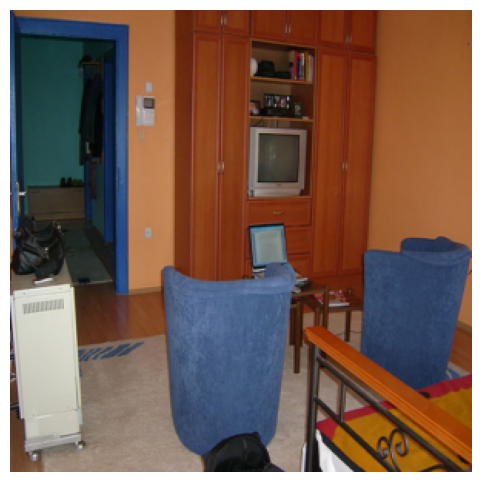

In [ ]:
idx = torch.randint(len(dataset), size = (1, ))
image, annotation = dataset[idx.item()]


plt.imshow(image.permute(1, 2, 0))
plt.grid(None)
plt.axis("off")
plt.show()

### 모델 예측

In [12]:
import time

idx = torch.randint(len(dataset), size = (1, ))
image_jpg, annotation = dataset[idx.item()]
image = image_jpg.unsqueeze(0).to(device)

ssd300.eval()
start = time.time()
with torch.no_grad():
    prediction = ssd300(image)
stop = time.time()
print(f"estimation time = {(stop - start)*1000:.3f}ms")
prediction = prediction[0] # batch remove
prediction

NameError: name 'dataset' is not defined

### Bounding box 그리기

[112, 65, 215, 183]


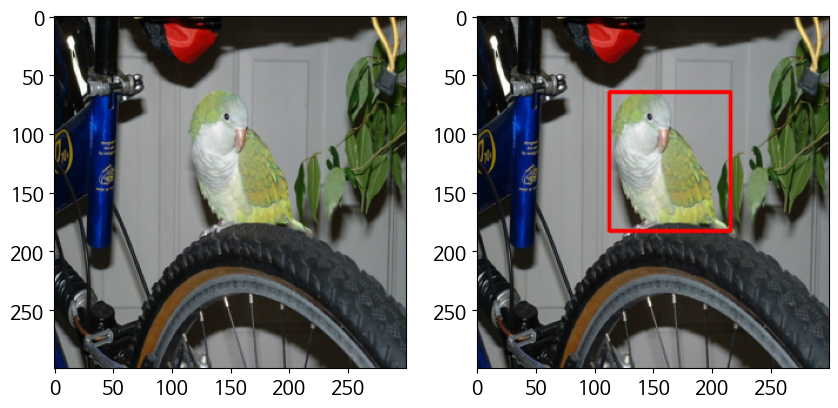

In [15]:

image = image.cpu().data[0]
image = transforms.functional.to_pil_image(image)
image = np.array(image)

threshold=0.5

for box, label, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
    if score > threshold:
        box = list(map(int, box))
        print(box)
        cv2.rectangle(image, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2, cv2.LINE_AA)

fig, axs = plt.subplots(1, 2, figsize = (10, 5))

axs[0].imshow(image_jpg.permute(1, 2, 0))
axs[0].grid(None)
axs[1].imshow(image)
axs[1].grid(None)
plt.show()
